In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


import sys
sys.path.append("../scripts")
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

In [3]:
data = pd.read_csv("../../Model/Data_Preparation/processed/m2or_pairs_model.csv", sep=",")
data

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


In [4]:
PREDICTION_THRESHOLD = 0.915

probabilities = pd.read_csv("../../Downstream_Analysis/predictions/aggregated/ASR_Predictions/asr_median_probability_wide.csv")
ligand_columns = [column for column in probabilities.columns if column.startswith("SML")]

predictions = probabilities.copy()
predictions[ligand_columns] = (probabilities[ligand_columns] > PREDICTION_THRESHOLD).astype(int)
predictions

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,node_100_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,node_101_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,node_102_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,node_103_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,node_104_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,node_96_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
428,node_97_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
429,node_98_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
430,node_99_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [5]:
smiles_map = (
    data[["smiles_id", "SMILES"]]
    .drop_duplicates()
    .rename(columns={"smiles_id": "SML_ID"})
)

In [6]:
smiles_map

,SML_ID,SMILES
0,SML0000,CC1=CC[C@H](CC1)C(=C)C
1,SML0001,CC1=CC[C@@H](CC1=O)C(=C)C
2,SML0002,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C
3,SML0003,CCCCO
4,SML0004,CCCCOCC(C)O
...,...,...
48316,SML0749,CCOC(=O)C(C)S
49585,SML0750,CC(=O)C1=CC2=CC=CC=C2C=C1
50146,SML0768,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C
50251,SML0769,C=CCSS(=O)CC=C


In [7]:
nodes_of_interest = ["node_1_ASR", "node_2_ASR", "node_3_ASR"]

pred_sub = predictions[predictions["protein_id"].isin(nodes_of_interest)].copy()
pred_sub

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
110,node_1_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
221,node_2_ASR,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
332,node_3_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [8]:
sml_cols = [c for c in pred_sub.columns if c != "protein_id"]

# long format
pred_long = pred_sub.melt(
    id_vars="protein_id",
    value_vars=sml_cols,
    var_name="SML_ID",
    value_name="active"
)

pred_long

,protein_id,SML_ID,active
0,node_1_ASR,SML0000,0
1,node_2_ASR,SML0000,0
2,node_3_ASR,SML0000,0
3,node_1_ASR,SML0001,0
4,node_2_ASR,SML0001,0
...,...,...,...
2257,node_2_ASR,SML0769,0
2258,node_3_ASR,SML0769,0
2259,node_1_ASR,SML0770,0
2260,node_2_ASR,SML0770,0


In [9]:
pred_active = pred_long[pred_long["active"] == 1].copy()
pred_active = pred_active.merge(smiles_map, on="SML_ID", how="left")

pred_active

,protein_id,SML_ID,active,SMILES
0,node_1_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
1,node_3_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
2,node_1_ASR,SML0014,1,CC1(C2CCC(=C)C1C2)C
3,node_2_ASR,SML0015,1,CC(=O)O
4,node_2_ASR,SML0016,1,CCCC(=O)O
...,...,...,...,...
415,node_1_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
416,node_3_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
417,node_1_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC
418,node_3_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC


In [10]:
node_counts = (
    pred_active.groupby("protein_id")["SMILES"]
    .nunique()
    .reset_index(name="n_unique_ligands")
)

node_counts

,protein_id,n_unique_ligands
0,node_1_ASR,177
1,node_2_ASR,130
2,node_3_ASR,113


In [11]:
node_ligands = (
    pred_active.groupby("protein_id")["SMILES"]
    .apply(list)
    .to_dict()
)

for node, ligs in node_ligands.items():
    print(f"\n{node}: {len(ligs)} ligands")
    print(ligs)


node_1_ASR: 177 ligands
['CC1=CCC2CC1C2(C)C', 'CC1(C2CCC(=C)C1C2)C', 'C1=CC=C2C(=C1)C=CC(=O)O2', 'CC(=CCC/C(=C/CC/C(=C/CO)/C)/C)C', 'CC(=CCC/C(=C/CO)/C)C', 'CC(CC1=CC=C(C=C1)C(C)(C)C)C=O', 'CC(=O)NCCC1=CNC2=C1C=C(C=C2)OC', 'CC1CCC2=NC=CN=C12', 'CC(=O)C1=NC=CN=C1', 'CCC(C)C1=NC=CN=C1OC', 'CC(CC=O)C1=CC=CC=C1', 'CC(=CCC/C(=C\\CO)/C)C', 'CCCCCOC(=O)C', 'C1CCC(=O)CC1', 'CC(=O)C1=CC=CC=C1', 'CC1C(=NC(S1)C)C', 'C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C', 'CCCCCCC/C=C/C=O', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@@]3(CCC(=O)C4)C', 'CCCCOC(=O)C', 'C1CCCCCC(=O)OCCOC(=O)CCCCC1', 'CC(=O)OC1=C(C=C(C=C1)CC=C)OC', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)CC[C@]34C', 'CC(=CCC/C(=C/COC(=O)C)/C)C', 'CC(=O)O[C@H]1C[C@H]2CC[C@]1(C2(C)C)C', 'C/C=C/C1=CC(=C(C=C1)O)OC', 'C1=CC=C(C=C1)CC=O', 'COC(=O)C1=CC=CC=C1', 'CC1=C(C=C(C=C1)[N+](=O)[O-])[N+](=O)[O-]', 'CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C', 'CC(C)C1=NC=CN=C1OC', 'CC(C)CC1=NC=CN=C1OC', 'CCCCCC/C=C/C=O', 'C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)

In [12]:
node_presence = (
    pred_active.assign(active=1)
    .pivot_table(
        index="SMILES",
        columns="protein_id",
        values="active",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

node_presence = node_presence.rename(columns={
    "node_1_ASR": "common_ancestor",
    "node_2_ASR": "class1_ancestor",
    "node_3_ASR": "class2_ancestor"
})

node_presence

protein_id,SMILES,common_ancestor,class1_ancestor,class2_ancestor
0,C(C(=O)C(=O)O)O,0,1,0
1,C(C(=O)O)N,0,1,0
2,C(C(=O)O)S,0,1,0
3,C(C(C(=O)O)N)N,0,1,0
4,C(C(C=O)O)O,0,1,0
...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,1,1,1
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,1,1,1


In [13]:
### evolutionary sets ###

common_set = set(node_presence.loc[node_presence["common_ancestor"] == 1, "SMILES"])
class1_set = set(node_presence.loc[node_presence["class1_ancestor"] == 1, "SMILES"])
class2_set = set(node_presence.loc[node_presence["class2_ancestor"] == 1, "SMILES"])

shared_all = common_set & class1_set & class2_set

class1_gains = class1_set - common_set
class2_gains = class2_set - common_set

class1_losses = common_set - class1_set
class2_losses = common_set - class2_set

print("Common ancestor ligands:", len(common_set))
print("Class 1 ancestor ligands:", len(class1_set))
print("Class 2 ancestor ligands:", len(class2_set))
print("Shared by all three:", len(shared_all))
print("Class 1 gains:", len(class1_gains))
print("Class 2 gains:", len(class2_gains))
print("Class 1 losses:", len(class1_losses))
print("Class 2 losses:", len(class2_losses))

Common ancestor ligands: 177
Class 1 ancestor ligands: 130
Class 2 ancestor ligands: 113
Shared by all three: 27
Class 1 gains: 89
Class 2 gains: 0
Class 1 losses: 136
Class 2 losses: 64


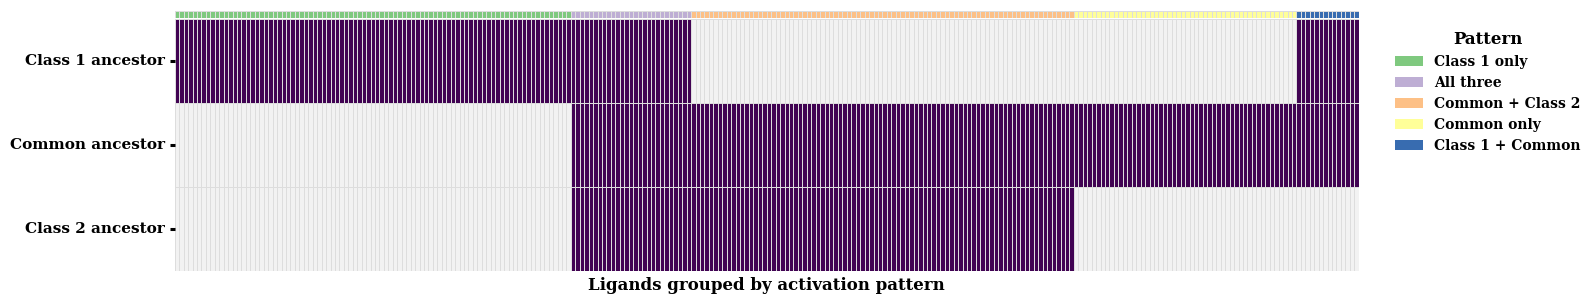

In [14]:
# build matrix from node_presence
X = (
    node_presence.set_index("SMILES")[["class1_ancestor", "common_ancestor", "class2_ancestor"]]
    .T
)

# rename rows for display
X.index = ["Class 1 ancestor", "Common ancestor", "Class 2 ancestor"]

# keep only ligands active in at least one node
X = X.loc[:, X.sum(axis=0) > 0]

# pattern per ligand (column), based on row order above
patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)

# readable order
pat_order = ["100", "111", "011", "010", "110"]

# sort columns by pattern
col_order = sorted(X.columns, key=lambda c: pat_order.index(patterns.loc[c]))
Xo = X[col_order]

# color strip for column patterns
pat_palette = dict(zip(pat_order, sns.color_palette("Accent", n_colors=len(pat_order))))
col_colors = patterns.loc[col_order].map(pat_palette).tolist()

# binary heatmap colors
bin_cmap = ListedColormap(["#f2f2f2", "#410353"])

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=bin_cmap,
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4,
    linecolor="#dddddd",
    figsize=(14, 3.2),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03)
)

# format heatmap axis
ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")

pattern_labels = {
    "100": "Class 1 only",
    "111": "All three",
    "011": "Common + Class 2",
    "010": "Common only",
    "110": "Class 1 + Common"
}

handles = [
    Patch(facecolor=pat_palette[p], edgecolor='none', label=pattern_labels[p])
    for p in pat_order
]


ax.legend(
    handles=handles,
    title="Pattern",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
plt.savefig("logp_transitions_human_ancestors_heatmap.svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

In [15]:
pattern_df = pd.DataFrame({
    "SMILES": X.columns,
    "pattern": patterns.loc[X.columns].values
})

pattern_df

,SMILES,pattern
0,C(C(=O)C(=O)O)O,100
1,C(C(=O)O)N,100
2,C(C(=O)O)S,100
3,C(C(C(=O)O)N)N,100
4,C(C(C=O)O)O,100
...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111


### Which subset of common ancestor remained in both his child and which subset of common ancestor’s ligands lost in total

In [16]:
fate_of_common = {
    "retained_in_both": set(pattern_df.loc[pattern_df["pattern"] == "111", "SMILES"]),
    "retained_only_in_class1": set(pattern_df.loc[pattern_df["pattern"] == "110", "SMILES"]),
    "retained_only_in_class2": set(pattern_df.loc[pattern_df["pattern"] == "011", "SMILES"]),
    "lost_in_both": set(pattern_df.loc[pattern_df["pattern"] == "010", "SMILES"]),
}

In [17]:
for k, v in fate_of_common.items():
    print(k, len(v))

retained_in_both 27
retained_only_in_class1 14
retained_only_in_class2 86
lost_in_both 50


In [18]:
sum(len(v) for v in fate_of_common.values()) == len(common_set)

True

In [19]:
pattern_name_map = {
    "100": "class1_gains",
    "111": "retained_in_both",
    "011": "retained_only_in_class2",
    "010": "lost_in_both",
    "110": "retained_only_in_class1",
}

compare_df = pattern_df.copy()
compare_df["group"] = compare_df["pattern"].map(pattern_name_map)

compare_df["group"].value_counts()

group
class1_gains               89
retained_only_in_class2    86
lost_in_both               50
retained_in_both           27
retained_only_in_class1    14
Name: count, dtype: int64

In [22]:
# descriptors
all_smiles = sorted(compare_df["SMILES"].unique())

desc_rows = []
for smi in all_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        desc_rows.append({
            "SMILES": smi,
            "logP": np.nan,
            "TPSA": np.nan,
            "MW": np.nan,
            "HBD": np.nan,
            "HBA": np.nan
        })
    else:
        desc_rows.append({
            "SMILES": smi,
            "logP": Descriptors.MolLogP(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "MW": Descriptors.MolWt(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol)
        })

desc_df = pd.DataFrame(desc_rows)

# functional groups
fg_smarts = {
    "carboxylic_acid": "[CX3](=O)[OX2H1]",
    "alcohol": "[OX2H][CX4;!$(C=O)]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "ester": "[CX3](=O)[OX2][#6]",
    "ether": "[OD2]([#6])[#6]",
    "amine": "[NX3;H2,H1,H0;!$(NC=O)]",
    "amide": "[NX3][CX3](=O)[#6]",
    "aromatic_ring": "a1aaaaa1",
    "phenol": "c[OX2H]",
    "nitrile": "[CX2]#N",
    "alkene": "[CX3]=[CX3]"
}

fg_patterns = {k: Chem.MolFromSmarts(v) for k, v in fg_smarts.items()}

mol_map = {smi: Chem.MolFromSmiles(smi) for smi in all_smiles}

fg_rows = []
for smi in all_smiles:
    mol = mol_map[smi]
    row = {"SMILES": smi}
    for fg_name, patt in fg_patterns.items():
        row[fg_name] = int(mol.HasSubstructMatch(patt)) if mol is not None else np.nan
    fg_rows.append(row)

fg_df = pd.DataFrame(fg_rows)

compare_df = (
    compare_df
    .merge(desc_df, on="SMILES", how="left")
    .merge(fg_df, on="SMILES", how="left")
)

In [24]:
compare_df

,SMILES,pattern,group,logP_x,TPSA_x,MW_x,HBD_x,HBA_x,carboxylic_acid_x,alcohol_x,...,aldehyde_y,ketone_y,ester_y,ether_y,amine_y,amide_y,aromatic_ring_y,phenol_y,nitrile_y,alkene_y
0,C(C(=O)C(=O)O)O,100,class1_gains,-1.3676,74.60,104.061,2,3,1,1,...,0,1,0,0,0,0,0,0,0,0
1,C(C(=O)O)N,100,class1_gains,-0.9703,63.32,75.067,2,2,1,0,...,0,0,0,0,1,0,0,0,0,0
2,C(C(=O)O)S,100,class1_gains,0.0008,37.30,92.119,2,2,1,0,...,0,0,0,0,0,0,0,0,0,0
3,C(C(C(=O)O)N)N,100,class1_gains,-1.6430,89.34,104.109,3,3,1,0,...,0,0,0,0,1,0,0,0,0,0
4,C(C(C=O)O)O,100,class1_gains,-1.4615,57.53,90.078,2,3,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111,retained_in_both,3.0598,54.37,302.414,1,3,0,1,...,0,1,0,0,0,0,0,0,0,1
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,retained_in_both,3.4891,37.30,274.404,1,2,0,1,...,0,1,0,0,0,0,0,0,0,1
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,retained_in_both,3.8792,37.30,288.431,1,2,0,1,...,0,1,0,0,0,0,0,0,0,1
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111,retained_in_both,3.8792,37.30,288.431,1,2,0,1,...,0,1,0,0,0,0,0,0,0,1


In [26]:
# Build compare_df correctly from pattern_df first
compare_df = pattern_df.copy()
compare_df["group"] = compare_df["pattern"].map(pattern_name_map)

# Then merge descriptors and functional groups
compare_df = (
    compare_df
    .merge(desc_df, on="SMILES", how="left")
    .merge(fg_df, on="SMILES", how="left")
)

In [27]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests

numeric_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]
group_order = [
    "class1_gains",
    "retained_only_in_class1",
    "retained_in_both",
    "retained_only_in_class2",
    "lost_in_both"
]

kw_results = []
for col in numeric_cols:
    samples = [
        compare_df.loc[compare_df["group"] == g, col].dropna().values
        for g in group_order
    ]
    stat, p = kruskal(*samples)
    kw_results.append({"descriptor": col, "H": stat, "p": p})

kw_df = pd.DataFrame(kw_results)
kw_df["p_adj"] = multipletests(kw_df["p"], method="fdr_bh")[1]
kw_df.sort_values("p_adj")

,descriptor,H,p,p_adj
3,HBD,102.087084,3.535397e-21,1.767698e-20
1,TPSA,99.985960,9.904557e-21,2.476139e-20
2,MW,41.152883,2.498877e-08,4.164795e-08
0,logP,22.799136,1.388792e-04,1.735990e-04
4,HBA,18.048600,1.207398e-03,1.207398e-03


In [28]:
def add_contrast_labels(df):
    df = df.copy()
    ancestral_retained = {"retained_in_both", "retained_only_in_class1", "retained_only_in_class2"}
    df["retention_status"] = np.where(df["group"].isin(ancestral_retained), "retained", 
                               np.where(df["group"] == "lost_in_both", "lost", "gain"))
    return df

analysis_df = add_contrast_labels(compare_df)

In [29]:
ret_vs_lost = analysis_df[analysis_df["retention_status"].isin(["retained", "lost"])].copy()

mw_results = []
for col in numeric_cols:
    x = ret_vs_lost.loc[ret_vs_lost["retention_status"] == "retained", col].dropna()
    y = ret_vs_lost.loc[ret_vs_lost["retention_status"] == "lost", col].dropna()
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    mw_results.append({
        "descriptor": col,
        "retained_median": x.median(),
        "lost_median": y.median(),
        "U": stat,
        "p": p
    })

mw_df = pd.DataFrame(mw_results)
mw_df["p_adj"] = multipletests(mw_df["p"], method="fdr_bh")[1]
mw_df.sort_values("p_adj")

,descriptor,retained_median,lost_median,U,p,p_adj
0,logP,2.580,2.5089,3396.0,0.472453,0.715314
1,TPSA,20.230,26.3000,3064.5,0.715314,0.715314
2,MW,165.236,162.2100,3390.5,0.483562,0.715314
3,HBD,0.000,0.0000,3461.5,0.196776,0.715314
4,HBA,1.000,2.0000,3019.0,0.588501,0.715314


In [32]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

numeric_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]
group_order = [
    "class1_gains",
    "retained_only_in_class1",
    "retained_in_both",
    "retained_only_in_class2",
    "lost_in_both"
]

pairwise_rows = []

for col in numeric_cols:
    for g1, g2 in combinations(group_order, 2):
        x = compare_df.loc[compare_df["group"] == g1, col].dropna()
        y = compare_df.loc[compare_df["group"] == g2, col].dropna()

        stat, p = mannwhitneyu(x, y, alternative="two-sided")

        pairwise_rows.append({
            "descriptor": col,
            "group1": g1,
            "group2": g2,
            "median1": x.median(),
            "median2": y.median(),
            "U": stat,
            "p": p
        })

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df["p_adj"] = multipletests(pairwise_df["p"], method="fdr_bh")[1]
pairwise_df = pairwise_df.sort_values(["descriptor", "p_adj", "p"])
pairwise_df

,descriptor,group1,group2,median1,median2,U,p,p_adj
47,HBA,retained_in_both,retained_only_in_class2,2.00000,1.00000,1709.5,7.519092e-05,3.759546e-04
41,HBA,class1_gains,retained_in_both,1.00000,2.00000,757.0,1.833630e-03,4.825341e-03
48,HBA,retained_in_both,lost_in_both,2.00000,2.00000,901.5,1.030326e-02,2.453157e-02
49,HBA,retained_only_in_class2,lost_in_both,1.00000,2.00000,1759.5,5.730011e-02,1.101925e-01
42,HBA,class1_gains,retained_only_in_class2,1.00000,1.00000,4324.5,1.006015e-01,1.642218e-01
44,HBA,retained_only_in_class1,retained_in_both,2.00000,2.00000,132.0,1.018175e-01,1.642218e-01
45,HBA,retained_only_in_class1,retained_only_in_class2,2.00000,1.00000,733.0,1.532515e-01,2.304433e-01
43,HBA,class1_gains,lost_in_both,1.00000,2.00000,2097.5,5.464224e-01,6.918692e-01
40,HBA,class1_gains,retained_only_in_class1,1.00000,2.00000,568.0,5.641589e-01,6.918692e-01
46,HBA,retained_only_in_class1,lost_in_both,2.00000,2.00000,358.0,8.954651e-01,9.526225e-01


In [31]:
def cliffs_delta(x, y):
    x = list(x)
    y = list(y)
    n1, n2 = len(x), len(y)
    gt = sum(1 for xi in x for yi in y if xi > yi)
    lt = sum(1 for xi in x for yi in y if xi < yi)
    return (gt - lt) / (n1 * n2)

/tmp/ipykernel_705492/4092309930.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_ns = plot_df.groupby("group")["SMILES"].nunique().reindex(group_order)
/tmp/ipykernel_705492/4092309930.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_705492/4092309930.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=10)
/tmp/ipykernel_705492/4092309930.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

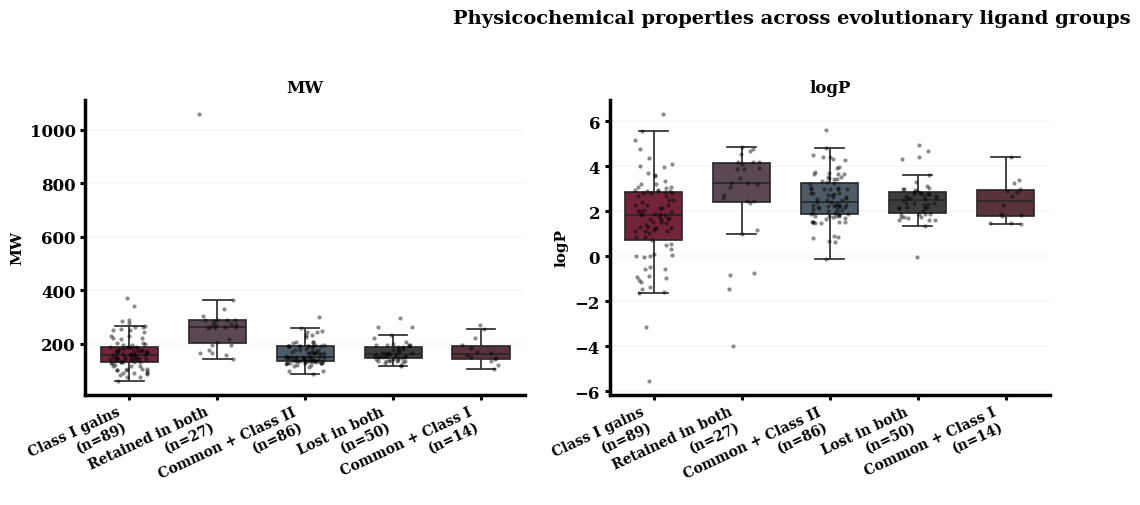

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# group order and colors
# -----------------------------
group_order = [
    "class1_gains",
    "retained_in_both",
    "retained_only_in_class2",
    "lost_in_both",
    "retained_only_in_class1",  
]

group_labels = {
    "class1_gains": "Class I gains",
    "retained_only_in_class1": "Common + Class I",
    "retained_in_both": "Retained in both",
    "retained_only_in_class2": "Common + Class II",
    "lost_in_both": "Lost in both"
}

group_palette = {
    "class1_gains": "#7f1734ff",           # class 1 gains
    "retained_in_both": "#5d4555ff",       # shared by all three
    "retained_only_in_class2": "#4a5d6bff",# common + class 2
    "lost_in_both": "#403e3dff",           # common only
    "retained_only_in_class1": "#5f2b38ff" # common + class 1
}

# -----------------------------
# descriptor columns to plot
# -----------------------------
#descriptor_cols = ["MW", "TPSA", "HBD", "logP", "HBA"]
descriptor_cols = ["MW", "logP"]

# make sure group is categorical in the right order
plot_df = compare_df.copy()
plot_df = plot_df[plot_df["group"].isin(group_order)].copy()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

# sample sizes for labels
group_ns = plot_df.groupby("group")["SMILES"].nunique().reindex(group_order)

x_labels = [
    f"{group_labels[g]}\n(n={group_ns[g]})"
    for g in group_order
]

# -----------------------------
# plotting
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(descriptor_cols):
    ax = axes[i]

    sns.boxplot(
        data=plot_df,
        x="group",
        y=col,
        order=group_order,
        palette=group_palette,
        width=0.65,
        linewidth=1.2,
        fliersize=0,
        ax=ax
    )

    sns.stripplot(
        data=plot_df,
        x="group",
        y=col,
        order=group_order,
        color="black",
        size=3,
        alpha=0.45,
        jitter=0.22,
        ax=ax
    )

    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=11)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax)

# remove empty panel
if len(descriptor_cols) < len(axes):
    for j in range(len(descriptor_cols), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle("Physicochemical properties across evolutionary ligand groups", fontsize=14, y=1.02)
plt.tight_layout()

# plt.savefig(
#     "ancestral_ligand_descriptor_boxplots.svg",
#     bbox_inches="tight",
#     transparent=True,
#     dpi=300
# )

plt.show()

/tmp/ipykernel_705492/3733588823.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_705492/3733588823.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=10)
/tmp/ipykernel_705492/3733588823.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_705492/3733588823.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=10)


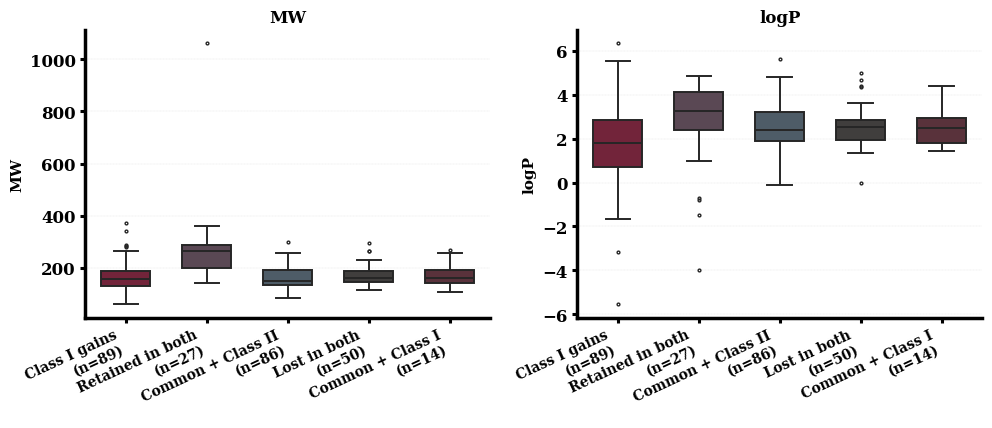

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes = axes.flatten()

for i, col in enumerate(descriptor_cols):
    ax = axes[i]

    sns.boxplot(
        data=plot_df,
        x="group",
        y=col,
        order=group_order,
        palette=group_palette,
        width=0.6,
        linewidth=1.4,
        fliersize=2,
        ax=ax
    )

    ax.set_title(col, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(col, fontsize=11)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.2)
    sns.despine(ax=ax)

if len(descriptor_cols) < len(axes):
    for j in range(len(descriptor_cols), len(axes)):
        fig.delaxes(axes[j])

#plt.suptitle("Physicochemical properties across evolutionary ligand groups", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_705492/3856254682.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")[fg_cols]


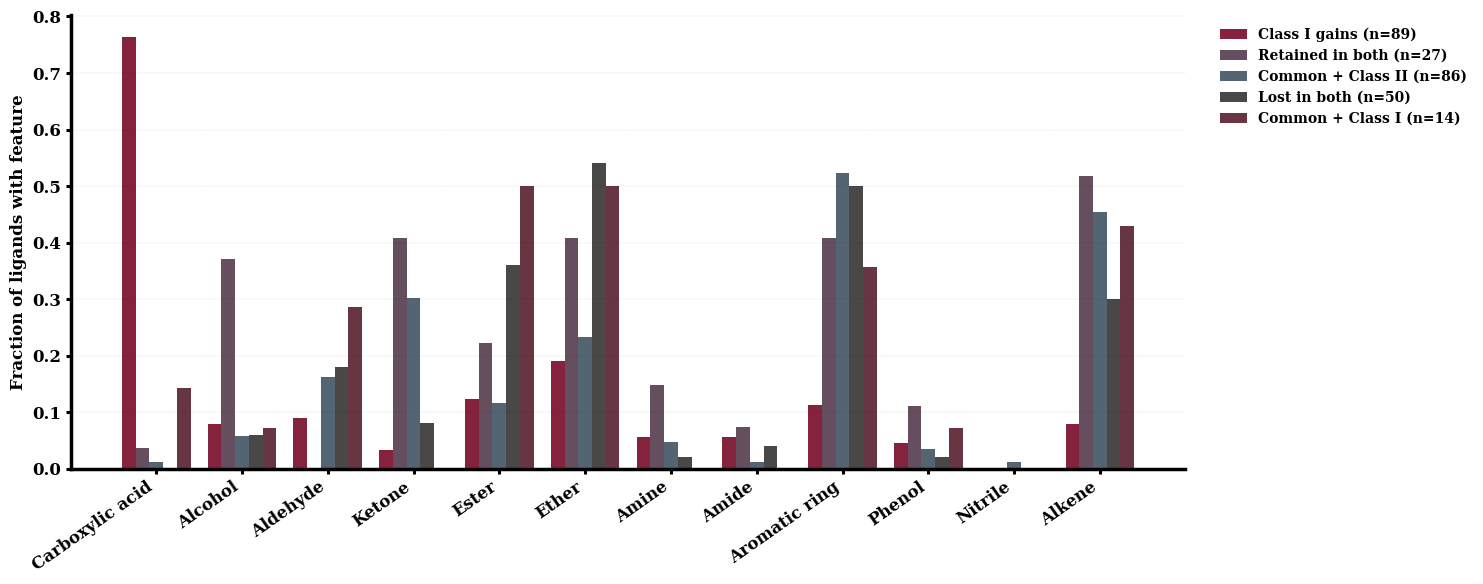

In [136]:
# functional group columns
fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester", "ether",
    "amine", "amide", "aromatic_ring", "phenol", "nitrile", "alkene"
]

fg_plot_df = compare_df.copy()
fg_plot_df = fg_plot_df[fg_plot_df["group"].isin(group_order)].copy()
fg_plot_df["group"] = pd.Categorical(fg_plot_df["group"], categories=group_order, ordered=True)

# fraction of ligands with each feature in each group
fg_summary = (
    fg_plot_df
    .groupby("group")[fg_cols]
    .mean()
    .T
)

# nicer labels
fg_labels = {
    "carboxylic_acid": "Carboxylic acid",
    "alcohol": "Alcohol",
    "aldehyde": "Aldehyde",
    "ketone": "Ketone",
    "ester": "Ester",
    "ether": "Ether",
    "amine": "Amine",
    "amide": "Amide",
    "aromatic_ring": "Aromatic ring",
    "phenol": "Phenol",
    "nitrile": "Nitrile",
    "alkene": "Alkene"
}

fg_summary.index = [fg_labels.get(x, x) for x in fg_summary.index]

# plot
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(fg_summary.index))
bar_width = 0.16

for i, g in enumerate(group_order):
    ax.bar(
        x + i * bar_width,
        fg_summary[g].values,
        width=bar_width,
        color=group_palette[g],
        label=f"{group_labels[g]} (n={group_ns[g]})",
        alpha=0.95
    )

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(fg_summary.index, rotation=35, ha="right")
ax.set_ylabel("Fraction of ligands with feature")
ax.set_xlabel("")
#ax.set_title("Functional-group composition across evolutionary ligand groups")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.25)
sns.despine(ax=ax)

plt.tight_layout()
# plt.savefig(
#     "ancestral_ligand_functional_groups_barplot.svg",
#     bbox_inches="tight",
#     transparent=True,
#     dpi=300
# )
plt.show()

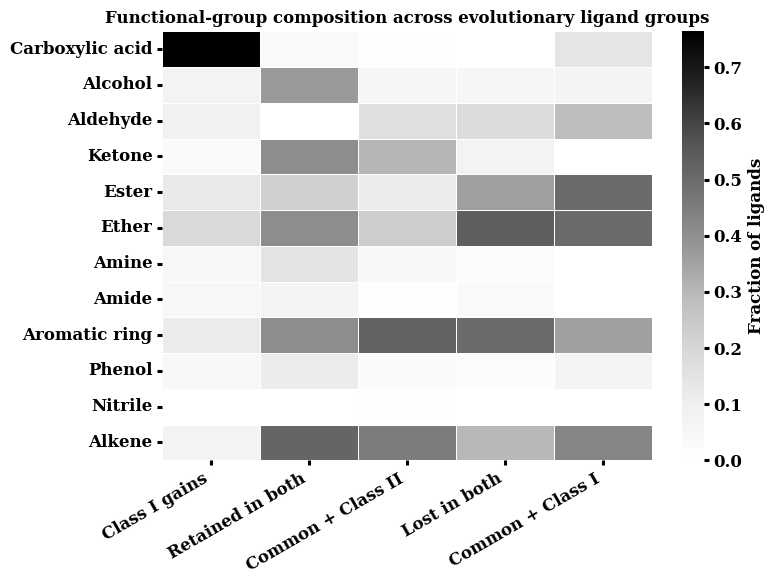

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    fg_summary[group_order],
    cmap="Greys",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Fraction of ligands"},
    ax=ax
)

ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Functional-group composition across evolutionary ligand groups")

plt.tight_layout()
# plt.savefig(
#     "ancestral_ligand_functional_groups_heatmap.svg",
#     bbox_inches="tight",
#     transparent=True,
#     dpi=300
# )
plt.show()

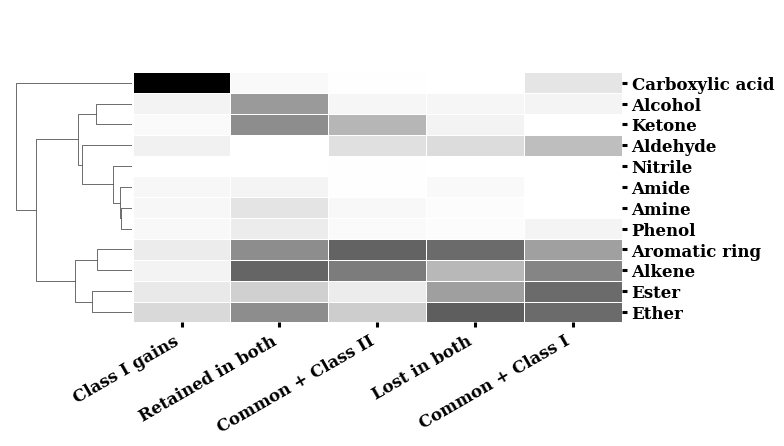

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# fixed column order
heat_df = fg_summary[group_order].copy()

cg = sns.clustermap(
    heat_df,
    row_cluster=True,
    col_cluster=False,
    cmap="Greys",
    linewidths=0.5,
    linecolor="white",
    figsize=(8, 6),
    #cbar_kws={"label": "Fraction of ligands"}
    cbar_pos=None
)

cg.ax_heatmap.set_xticklabels(
    [group_labels[g] for g in group_order],
    rotation=30,
    ha="right"
)
cg.ax_heatmap.set_xlabel("")
cg.ax_heatmap.set_ylabel("")
#cg.ax_heatmap.set_title("Functional-group composition across evolutionary ligand groups", pad=12)

plt.show()

In [53]:
odors = pd.read_csv("../../Chemicals/odor_datasets/inchi_odors_smiles.csv")
odors

,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,FYGHSUNMUKGBRK-UHFFFAOYSA-N,CC1=C(C(=CC=C1)C)C,NaN
4,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"balsamic, winey, oily, solvent, fermented, swe..."
...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"meaty, fruity, sulfurous"
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orangeflower, powdery, honey, sweet, floral, o..."
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green"
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN


In [54]:
import pandas as pd
import numpy as np

odors = pd.read_csv("../../Chemicals/odor_datasets/inchi_odors_smiles.csv")
odor_df = odors[["SMILES", "Odors"]].copy()
odor_df = odor_df.dropna(subset=["Odors"]).copy()
odor_df["odor_tag"] = odor_df["Odors"].str.split(",")

odor_long = odor_df.explode("odor_tag").copy()

odor_long["odor_tag"] = (
    odor_long["odor_tag"]
    .astype(str)
    .str.strip()
    .str.lower()
)

odor_long = odor_long[odor_long["odor_tag"] != ""].copy()

odor_long = odor_long.drop_duplicates(["SMILES", "odor_tag"]).reset_index(drop=True)

odor_long

,SMILES,Odors,odor_tag
0,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",terpenic
1,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",peppery
2,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",herbal
3,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",pine
4,CC1=CC[C@H](CC1)C(=C)C,"terpenic, peppery, herbal, pine, orange",orange
...,...,...,...
3747,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green",earthy
3748,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green",fresh
3749,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"herbal, musty, earthy, fresh, green",green
3750,CC1=CC2=C(C=C1)C(CC=C2)(C)C,"gasoline, woody",gasoline


In [56]:
odor_group_df = odor_long.merge(
    compare_df[["SMILES", "group"]].drop_duplicates(),
    on="SMILES",
    how="inner"
)

odor_group_df

,SMILES,Odors,odor_tag,group
0,CC1=CCC2CC1C2(C)C,"terpenic, cooling, herbal, sweet, camphoreous,...",terpenic,retained_only_in_class2
1,CC1=CCC2CC1C2(C)C,"terpenic, cooling, herbal, sweet, camphoreous,...",cooling,retained_only_in_class2
2,CC1=CCC2CC1C2(C)C,"terpenic, cooling, herbal, sweet, camphoreous,...",herbal,retained_only_in_class2
3,CC1=CCC2CC1C2(C)C,"terpenic, cooling, herbal, sweet, camphoreous,...",sweet,retained_only_in_class2
4,CC1=CCC2CC1C2(C)C,"terpenic, cooling, herbal, sweet, camphoreous,...",camphoreous,retained_only_in_class2
...,...,...,...,...
1149,CCCCCC(C)C(=O)O,"cheesy, fatty, green, waxy, sour",green,class1_gains
1150,CCCCCC(C)C(=O)O,"cheesy, fatty, green, waxy, sour",waxy,class1_gains
1151,CCCCCC(C)C(=O)O,"cheesy, fatty, green, waxy, sour",sour,class1_gains
1152,C1C2CC(C1C=C2)C(=O)O,"green, fruity",green,class1_gains


In [57]:
annot_counts = (
    odor_group_df[["SMILES", "group"]]
    .drop_duplicates()
    .groupby("group")
    .size()
    .reindex(group_order)
)

annot_counts

group
class1_gains               53
retained_in_both            9
retained_only_in_class2    67
lost_in_both               39
retained_only_in_class1    13
dtype: int64

In [59]:
tag_counts = (
    odor_group_df.groupby("odor_tag")["SMILES"]
    .nunique()
    .sort_values(ascending=False)
)

tag_counts

odor_tag
sweet           86
fruity          65
floral          56
green           52
fatty           39
                ..
malty            1
popcorn          1
orangeflower     1
hazelnut         1
geranium         1
Name: SMILES, Length: 139, dtype: int64

/tmp/ipykernel_705492/4182155891.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


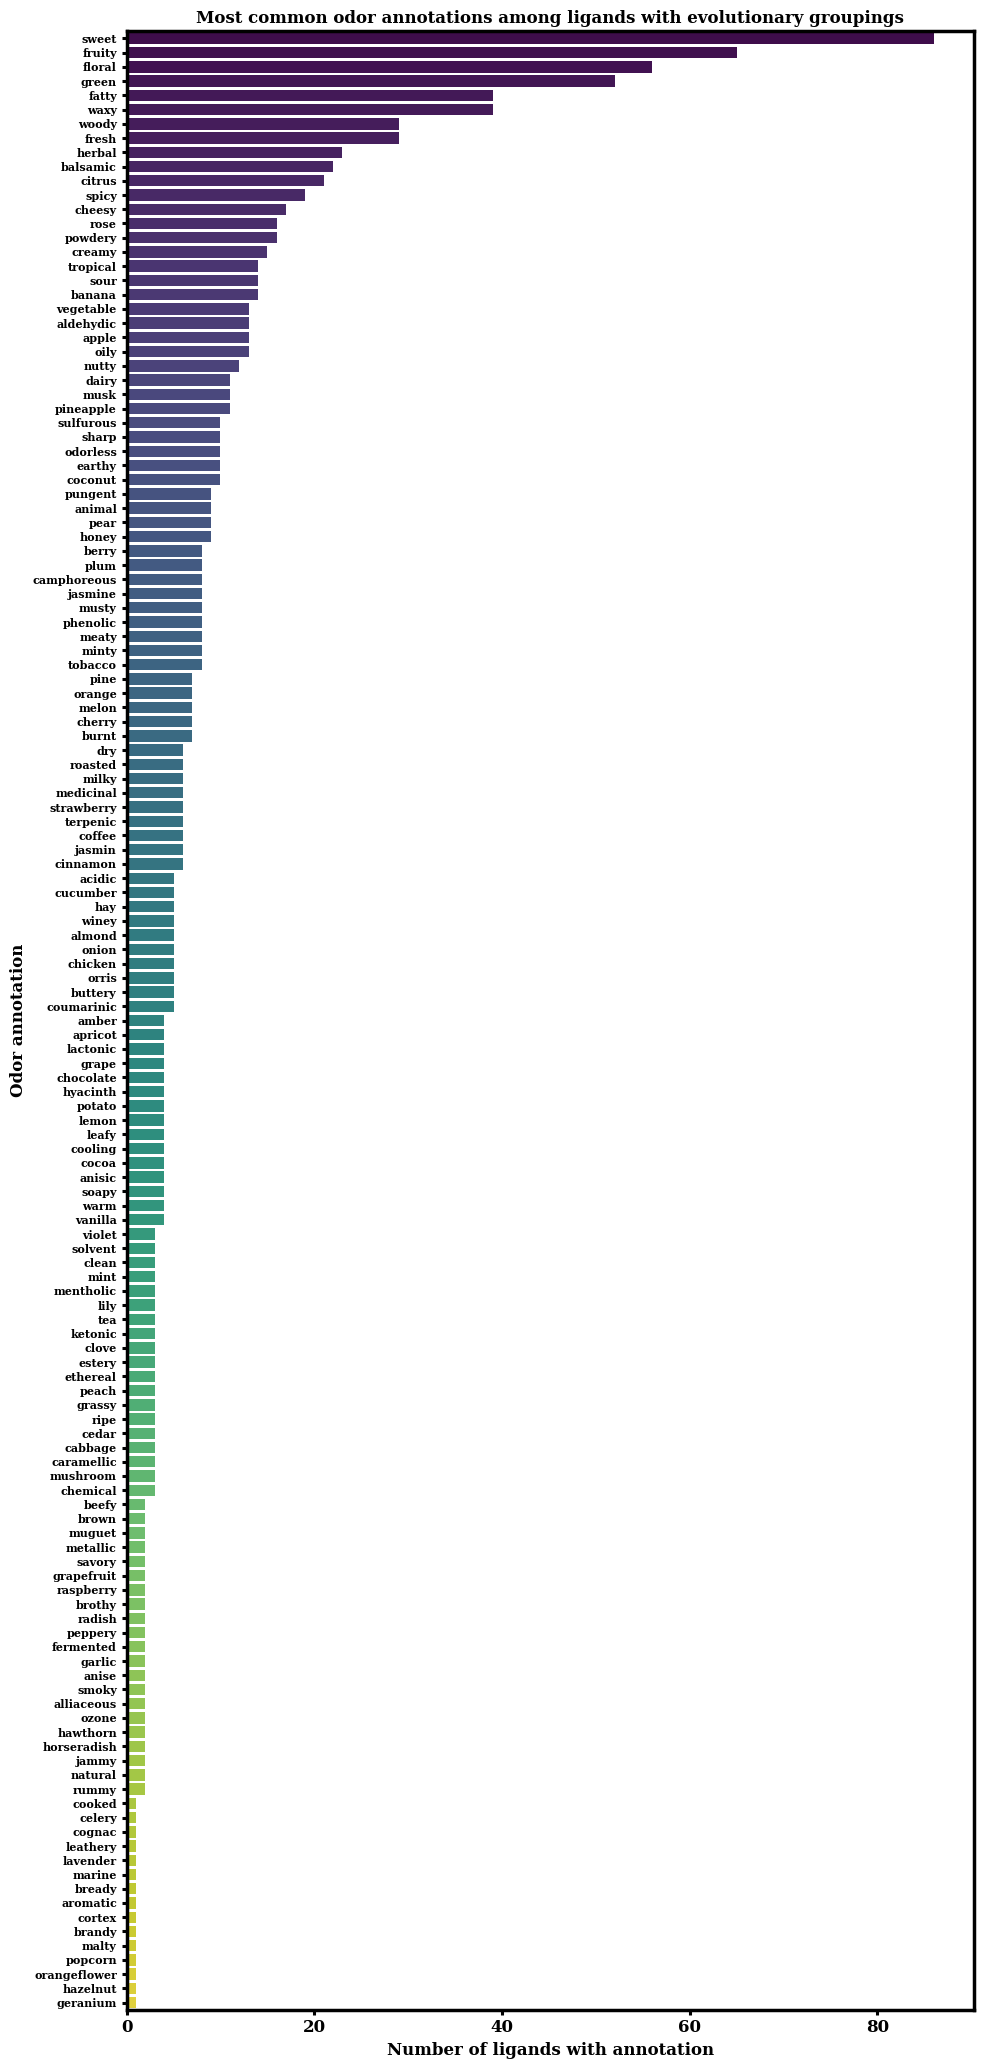

In [66]:
import math

n = len(tag_counts)

plt.figure(figsize=(10, max(6, 0.15 * n)))
ax = sns.barplot(
    x=tag_counts.values,
    y=tag_counts.index,
    palette="viridis"
)
# plt.figure(figsize=(max(6, 0.25 * n), 10))
# ax = sns.barplot(
#     x=tag_counts.index,
#     y=tag_counts.values,
#     palette="viridis"
# )


ax.set_xlabel("Number of ligands with annotation")
ax.set_ylabel("Odor annotation")
ax.set_title("Most common odor annotations among ligands with evolutionary groupings")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [109]:
min_tag_size = 8

common_tags = tag_counts[tag_counts >= min_tag_size].index

odor_group_df_filt = odor_group_df[odor_group_df["odor_tag"].isin(common_tags)].copy()

print("Number of tags kept:", odor_group_df_filt["odor_tag"].nunique())
print("Number of ligand-tag rows kept:", len(odor_group_df_filt))

Number of tags kept: 45
Number of ligand-tag rows kept: 841


In [110]:
annot_counts_after_filter = (
    odor_group_df_filt[["SMILES", "group"]]
    .drop_duplicates()
    .groupby("group")
    .size()
    .reindex(group_order)
)

annot_counts_after_filter

group
class1_gains               53
retained_in_both            9
retained_only_in_class2    67
lost_in_both               39
retained_only_in_class1    13
dtype: int64

odor_tag
sweet     86
fruity    65
floral    56
green     52
waxy      39
Name: SMILES, dtype: int64
Number of common tags: 45


/tmp/ipykernel_705492/4239973140.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


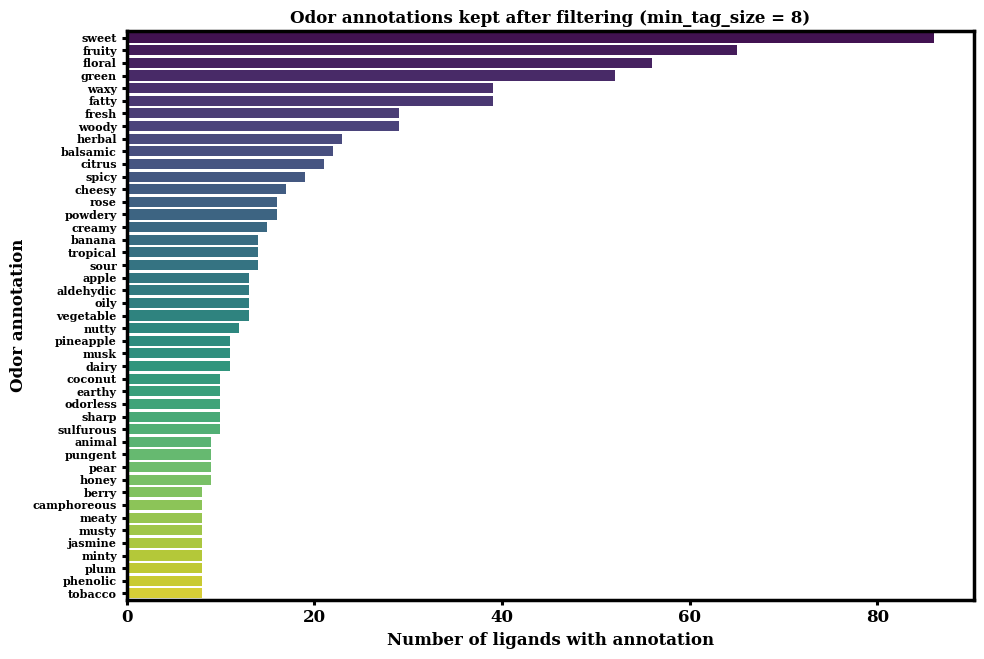

In [111]:
# counts after filtering to common tags
common_tag_counts = (
    odor_group_df_filt.groupby("odor_tag")["SMILES"]
    .nunique()
    .sort_values(ascending=False)
)

print(common_tag_counts.head())
print("Number of common tags:", len(common_tag_counts))

plt.figure(figsize=(10, max(6, 0.15 * len(common_tag_counts))))
ax = sns.barplot(
    x=common_tag_counts.values,
    y=common_tag_counts.index,
    palette="viridis"
)

ax.set_xlabel("Number of ligands with annotation")
ax.set_ylabel("Odor annotation")
ax.set_title(f"Odor annotations kept after filtering (min_tag_size = {min_tag_size})")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [112]:
all_smiles_universe = set(compare_df["SMILES"])

group_sets = {
    g: set(compare_df.loc[compare_df["group"] == g, "SMILES"])
    for g in group_order
}

tag_sets = {
    tag: set(odor_group_df_filt.loc[odor_group_df_filt["odor_tag"] == tag, "SMILES"])
    for tag in sorted(odor_group_df_filt["odor_tag"].unique())
}

In [113]:
### Tests whether a given tag is overrepresented in a group compared with ligands from the same universe ###

def permutation_enrichment(group_smiles, all_smiles, tag_smiles, n_perm=9999, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    group_smiles = set(group_smiles)
    tag_smiles = set(tag_smiles)
    all_smiles = np.array(list(all_smiles))

    obs = len(group_smiles & tag_smiles)
    group_size = len(group_smiles)

    null_counts = np.array([
        len(set(rng.choice(all_smiles, size=group_size, replace=False)) & tag_smiles)
        for _ in range(n_perm)
    ])

    exp = null_counts.mean()
    p = (np.sum(null_counts >= obs) + 1) / (n_perm + 1)
    enrichment = obs / (exp + 1e-9)

    return obs, exp, enrichment, p

In [114]:
from statsmodels.stats.multitest import multipletests

rows = []

rng = np.random.default_rng(42)

for group_name, gset in group_sets.items():
    for tag, tset in tag_sets.items():
        obs, exp, enrich, p = permutation_enrichment(
            group_smiles=gset,
            all_smiles=all_smiles_universe,
            tag_smiles=tset,
            n_perm=9999,
            rng=rng
        )

        rows.append({
            "group": group_name,
            "odor_tag": tag,
            "obs": obs,
            "exp": exp,
            "enrichment": enrich,
            "p": p,
            "group_size": len(gset),
            "tag_size": len(tset)
        })

enrich_df = pd.DataFrame(rows)

enrich_df["p_adj"] = multipletests(enrich_df["p"], method="fdr_bh")[1]

enrich_df = enrich_df.sort_values(["group", "p_adj", "enrichment"], ascending=[True, True, False])

enrich_df

,group,odor_tag,obs,exp,enrichment,p,group_size,tag_size,p_adj
26,class1_gains,odorless,10,3.345235,2.989327,0.0001,89,10,0.011250
36,class1_gains,sour,14,4.688669,2.985922,0.0001,89,14,0.011250
43,class1_gains,waxy,25,13.062906,1.913816,0.0002,89,39,0.015000
7,class1_gains,cheesy,14,5.661066,2.473032,0.0003,89,17,0.016875
13,class1_gains,fatty,22,13.059606,1.684584,0.0007,89,39,0.031500
...,...,...,...,...,...,...,...,...,...
99,retained_only_in_class2,coconut,0,3.230323,0.000000,1.0000,86,10,1.000000
101,retained_only_in_class2,dairy,0,3.567957,0.000000,1.0000,86,11,1.000000
116,retained_only_in_class2,odorless,0,3.258126,0.000000,1.0000,86,10,1.000000
120,retained_only_in_class2,pineapple,0,3.549055,0.000000,1.0000,86,11,1.000000


In [115]:
sig_enrich = enrich_df[
    (enrich_df["enrichment"] > 1) & (enrich_df["obs"] >= 3) & (enrich_df["p"] <= 0.05)
].copy()

sig_enrich.sort_values(["group", "p", "enrichment"], ascending=[True, True, False])

,group,odor_tag,obs,exp,enrichment,p,group_size,tag_size,p_adj
26,class1_gains,odorless,10,3.345235,2.989327,0.0001,89,10,0.011250
36,class1_gains,sour,14,4.688669,2.985922,0.0001,89,14,0.011250
43,class1_gains,waxy,25,13.062906,1.913816,0.0002,89,39,0.015000
7,class1_gains,cheesy,14,5.661066,2.473032,0.0003,89,17,0.016875
13,class1_gains,fatty,22,13.059606,1.684584,0.0007,89,39,0.031500
11,class1_gains,dairy,9,3.674567,2.449268,0.0016,89,11,0.060000
30,class1_gains,pineapple,8,3.691769,2.166983,0.0079,89,11,0.148125
9,class1_gains,coconut,7,3.376538,2.073130,0.0197,89,10,0.233289
10,class1_gains,creamy,9,5.021602,1.792257,0.0273,89,15,0.279205
143,lost_in_both,citrus,8,3.926793,2.037286,0.0251,50,21,0.279205


/tmp/ipykernel_705492/1607032701.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")


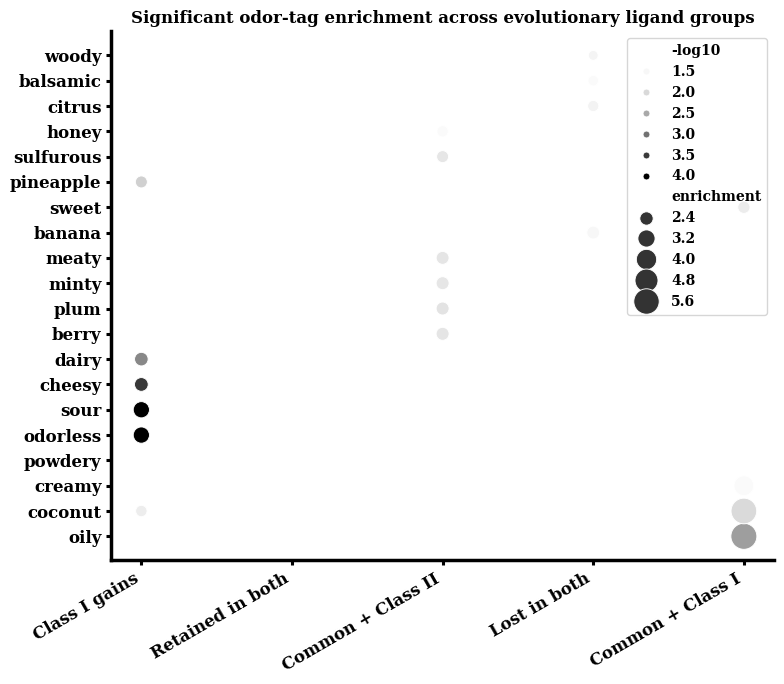

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# choose top tags per group, e.g. top 5 by enrichment then p_adj
top_sig = (
    sig_enrich.sort_values(["group", "enrichment", "p"], ascending=[True, False, True])
    .groupby("group")
    .head(6)
    .copy()
)

# to avoid duplicates, keep unique rows
top_sig = top_sig.drop_duplicates(["group", "odor_tag"])

# order tags by average enrichment across selected rows
tag_order = (
    top_sig.groupby("odor_tag")["enrichment"]
    .mean()
    .sort_values()
    .index
)

plot_df = top_sig.copy()
plot_df["odor_tag"] = pd.Categorical(plot_df["odor_tag"], categories=tag_order, ordered=True)
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)
plot_df["-log10"] = -np.log10(plot_df["p"].astype(float))

fig, ax = plt.subplots(figsize=(8, max(4, len(tag_order) * 0.35)))

sns.scatterplot(
    data=plot_df,
    x="group",
    y="odor_tag",
    size="enrichment",
    hue="-log10",
    sizes=(50, 350),
    palette="Greys",
    ax=ax,
    legend="brief"
)

ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Significant odor-tag enrichment across evolutionary ligand groups")

sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig("odor_tag_enrichment_dotplot.svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

/tmp/ipykernel_705492/3775376586.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")


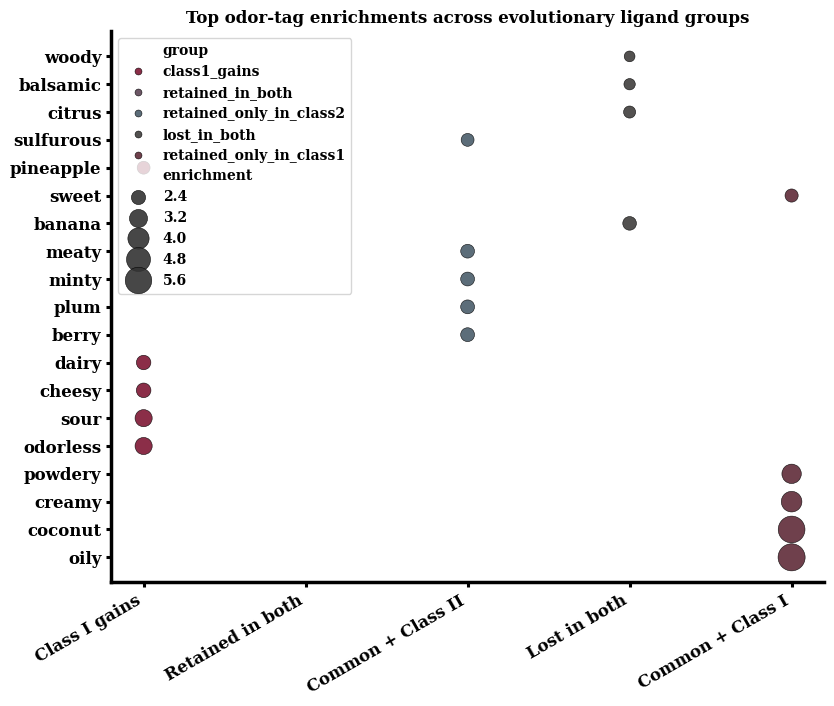

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# choose top tags per group
top_sig = (
    sig_enrich.sort_values(["group", "enrichment", "p"], ascending=[True, False, True])
    .groupby("group")
    .head(5)
    .copy()
)

top_sig = top_sig.drop_duplicates(["group", "odor_tag"])

# order tags by average enrichment
tag_order = (
    top_sig.groupby("odor_tag")["enrichment"]
    .mean()
    .sort_values()
    .index
)

plot_df = top_sig.copy()
plot_df["odor_tag"] = pd.Categorical(plot_df["odor_tag"], categories=tag_order, ordered=True)
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)
plot_df["neglog10_fdr"] = -np.log10(plot_df["p"].astype(float))

fig, ax = plt.subplots(figsize=(8.5, max(4, len(tag_order) * 0.38)))

sns.scatterplot(
    data=plot_df,
    x="group",
    y="odor_tag",
    size="enrichment",
    hue="group",
    palette=group_palette,
    sizes=(60, 380),
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    ax=ax,
    legend="brief"
)

ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Top odor-tag enrichments across evolutionary ligand groups")

sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig("odor_tag_enrichment_dotplot_groupcolors.svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

/tmp/ipykernel_705492/2518012171.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")


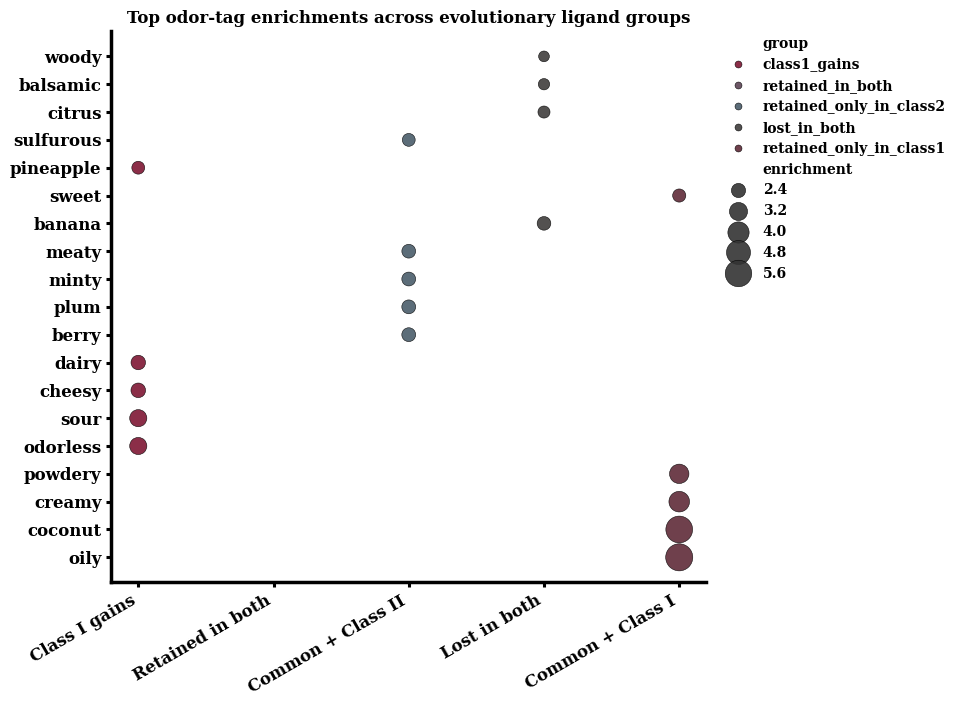

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# choose top tags per group
top_sig = (
    sig_enrich.sort_values(["group", "enrichment", "p"], ascending=[True, False, True])
    .groupby("group")
    .head(5)
    .copy()
)

top_sig = top_sig.drop_duplicates(["group", "odor_tag"])

# order tags by average enrichment
tag_order = (
    top_sig.groupby("odor_tag")["enrichment"]
    .mean()
    .sort_values()
    .index
)

plot_df = top_sig.copy()
plot_df["odor_tag"] = pd.Categorical(plot_df["odor_tag"], categories=tag_order, ordered=True)
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)
plot_df["neglog10_fdr"] = -np.log10(plot_df["p"].astype(float))

fig, ax = plt.subplots(figsize=(12, max(4, len(tag_order) * 0.38)))

sns.scatterplot(
    data=plot_df,
    x="group",
    y="odor_tag",
    size="enrichment",
    hue="group",
    palette=group_palette,
    sizes=(60, 380),
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    ax=ax,
    legend="brief"
)

ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Top odor-tag enrichments across evolutionary ligand groups")

# move legend outside
leg = ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

sns.despine(ax=ax)

# leave room for legend on the right
plt.tight_layout(rect=[0, 0, 0.82, 1])

# plt.savefig("odor_tag_enrichment_dotplot_groupcolors.svg",
#             bbox_inches="tight", transparent=True, dpi=300)
plt.show()

/tmp/ipykernel_705492/1096932529.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")


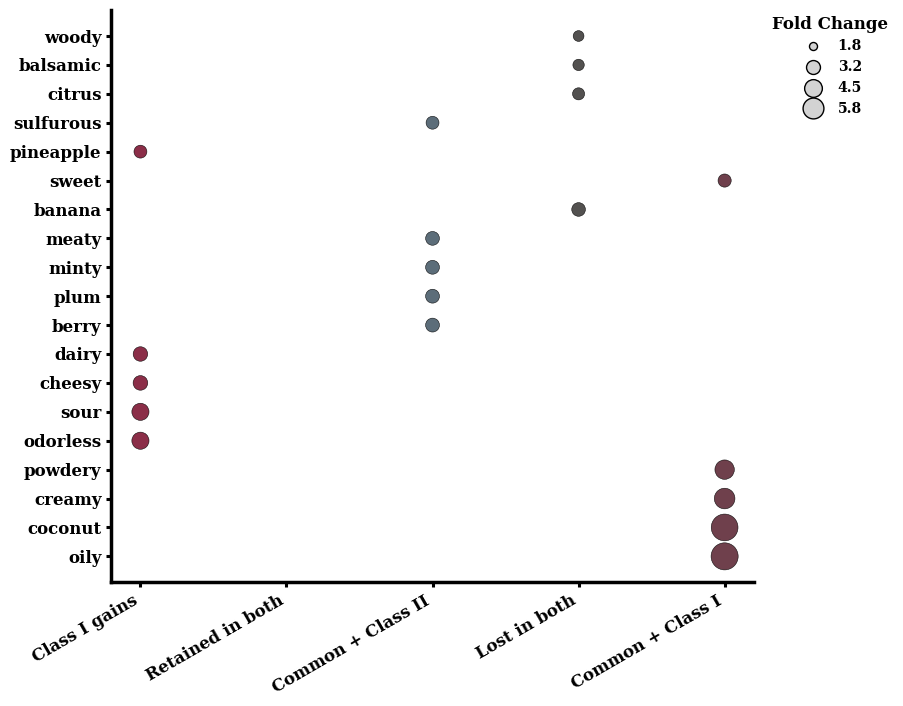

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# choose top tags per group
top_sig = (
    sig_enrich.sort_values(["group", "enrichment", "p"], ascending=[True, False, True])
    .groupby("group")
    .head(5)
    .copy()
)

top_sig = top_sig.drop_duplicates(["group", "odor_tag"])

# order tags by average enrichment
tag_order = (
    top_sig.groupby("odor_tag")["enrichment"]
    .mean()
    .sort_values()
    .index
)

plot_df = top_sig.copy()
plot_df["odor_tag"] = pd.Categorical(plot_df["odor_tag"], categories=tag_order, ordered=True)
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

fig, ax = plt.subplots(figsize=(11, max(4, len(tag_order) * 0.38)))

sns.scatterplot(
    data=plot_df,
    x="group",
    y="odor_tag",
    size="enrichment",
    hue="group",
    palette=group_palette,
    sizes=(60, 380),
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9,
    ax=ax,
    legend=False   # <- no automatic legend
)

ax.set_xticklabels([group_labels[g] for g in group_order], rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("")
#ax.set_title("Top odor-tag enrichments across evolutionary ligand groups")

# -----------------------------
# custom size legend only
# -----------------------------
size_vals = np.round(
    np.linspace(plot_df["enrichment"].min(), plot_df["enrichment"].max(), 4),
    1
)
size_min, size_max = 60, 380
data_min, data_max = plot_df["enrichment"].min(), plot_df["enrichment"].max()

def scale_size(v, vmin=data_min, vmax=data_max, smin=size_min, smax=size_max):
    if vmax == vmin:
        return (smin + smax) / 2
    return smin + (v - vmin) * (smax - smin) / (vmax - vmin)

size_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=np.sqrt(scale_size(v)) / 1.3,
        markerfacecolor='lightgray',
        markeredgecolor='black',
        label=f"{v:.1f}"
    )
    for v in size_vals
]

leg = ax.legend(
    handles=size_handles,
    title="Fold Change",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

sns.despine(ax=ax)
plt.tight_layout(rect=[0, 0, 0.84, 1])

plt.savefig("odor_tag_enrichment_dotplot_sizelegend_only.png",
             bbox_inches="tight", transparent=True, dpi=300)
plt.show()